<a href="https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_05/code_examples/example_04_beta_si3n4_multislice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Week 05 - Example 04: Multislice Simulation of Si3N4

This notebook demonstrates a complete multislice simulation for a non-cubic crystal: **Beta Silicon Nitride**.

We will:
1.  Define the crystal structure and convert the hexagonal unit cell to a larger **rectangular supercell** suitable for FFT-based multislice.
2.  Generate the projected potentials for the slices.
3.  Perform the multislice propagation loop.
4.  Visualize the exit wave and simulate TEM images at different defocus values.

References:
*   Kirkland, E. J. *Advanced Computing in Electron Microscopy*. (Figures 7.9 - 7.12)

## 1. Import Libraries and Parameters

We use `numpy` for calculations and `matplotlib` for display. 

**Simulation Parameters:**
*   Energy: 200 keV ($\lambda \approx 0.0251$ Å)
*   Lattice Constants ($P6_3/m$): $a = 7.606$ Å, $c = 2.909$ Å.
*   Supercell: $5 a_{rect} \times 3 b_{rect}$ based on the rectangular cell definition ($a_{rect}=a$, $b_{rect}=a\sqrt{3}$).
*   Grid: $256 \times 256$ pixels.
*   Pixel Size: $\Delta x \approx 0.15$ Å.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Physical Constants ---
h = 6.62607015e-34    # Planck's constant [J s]
m0 = 9.10938356e-31   # Electron rest mass [kg]
e = 1.602176634e-19   # Elementary charge [C]
c = 2.99792458e8      # Speed of light [m/s]

def get_wavelength_sigma(voltage_kv):
    """
    Calculates the relativistic electron wavelength and the interaction parameter (sigma).
    
    Args:
        voltage_kv (float): Accelerating voltage in kilovolts.
        
    Returns:
        tuple: (wavelength in Angstroms, sigma in SI units [rad / V m])
    """
    V = voltage_kv * 1000
    E0 = m0 * c**2
    
    # Relativistic factors
    # gamma: Lorentz factor, how much mass increases
    gamma = 1 + (e * V) / E0
    beta = np.sqrt(1 - 1/gamma**2)
    
    # Relativistic Wavelength (lambda = h / p)
    lam = h / (np.sqrt(2 * m0 * e * V * (1 + e * V / (2 * E0))))
    
    # Interaction parameter sigma (rad / V m)
    # This defines how much phase shift the electron wave acquires per volt of potential.
    sigma = (2 * np.pi * m0 * e * lam) / (h**2) * gamma
    
    return lam * 1e10, sigma # return wavelength in Angstroms, sigma in SI

voltage = 200.0
lam, sigma_SI = get_wavelength_sigma(voltage)

# Convert sigma to units compatible with Angstroms
# The phase shift is calculation: phi(x) = sigma * Integral( V(x,y,z) dz )
# If V is in Volts and dz is in Angstroms, the product has units [V * A].
# Therefore, we need sigma in units of [rad / (V * A)].
# Since 1 m = 1e10 A, we divide the SI sigma by 1e10.
sigma = sigma_SI / 1e10

print(f"Energy: {voltage} kV")
print(f"Wavelength: {lam:.4f} Å")
print(f"Interaction sigma: {sigma:.4e} rad/(V·Å)")

Energy: 200.0 kV
Wavelength: 0.0251 Å
Interaction sigma: 7.2884e-04 rad/(V·Å)


## 2. Generate Structure (Hexagonal to Rectangular)

$\beta$-Si$_3$N$_4$ is hexagonal. To use FFTs efficiently, we transform it into an orthorhombic/rectangular supercell.
*   $a_{hex} = 7.606$ Å, $c_{hex} = 2.909$ Å.
*   Rectangular cell: $a' = a_{hex}$, $b' = a_{hex} \sqrt{3} \approx 13.174$ Å, $c' = c_{hex}$.

The atoms in the unit cell (approximate positions derived from standard P63/m structure for $\beta$-Si$_3$N$_4$) are defined below. We populate the rectangular cell.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Generated 28 atoms in one rectangular cell (Target: 28).
Supercell Dimensions: 38.03 x 39.52 Å
Total atoms: 420


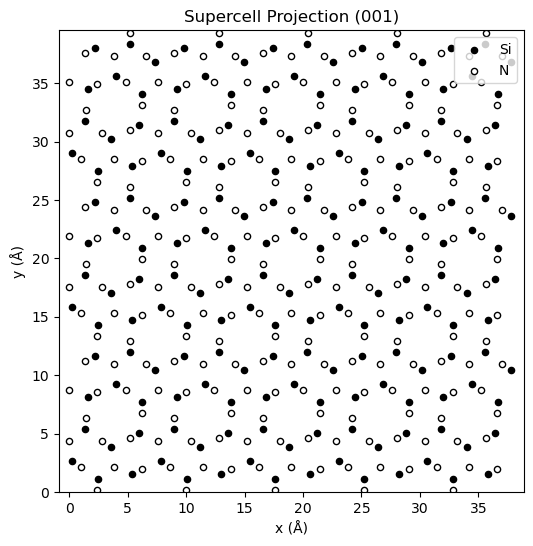

In [2]:
# Lattice constants for Beta-Si3N4
a_hex = 7.606   # Angstroms
c_hex = 2.909   # Angstroms

# To define a rectangular simulation box (required for 2D FFT), 
# we define a supercell based on the hexagonal lattice vectors:
# a_rect = a_hex
# b_rect = a_hex * sqrt(3)
# This box contains exactly 2 hexagonal unit cells in volume.
a_rect = a_hex
b_rect = a_hex * np.sqrt(3)

def get_beta_si3n4_rect_atoms():
    """
    Returns list of atoms in the rectangular unit cell (a_rect x b_rect x c_hex).
    
    Structure generation strategy:
    1. Define atoms in the primitive Hexagonal cell using standard Wyckoff positions.
    2. Map these atoms to Cartesian coordinates.
    3. Replicate the atoms to fill the volume of the Rectangular supercell.
    """
    
    # --- Step 1: Define Hexagonal Unit Cell Atoms ---
    # Wyckoff positions generator for P63/m (Space Group #176)
    
    def generate_6h(elem, x, y):
        # 6h Wyckoff site symmetry operations for z=1/4 plane
        w_ops = [
            (x, y, 0.25),
            (-y, x-y, 0.25),
            (-x+y, -x, 0.25),
            (-x, -y, 0.75),
            (y, -x+y, 0.75),
            (x-y, x, 0.75)
        ]
        return [(elem, u, v, w) for u, v, w in w_ops]

    def generate_2c(elem):
        # 2c Wyckoff site (typically N atoms in this structure)
        return [(elem, 1/3, 2/3, 0.25), (elem, 2/3, 1/3, 0.75)]
        
    # Fractional coordinates for Beta-Si3N4 (Literature values)
    # Si (6h site)
    u_si, v_si = 0.174, -0.233
    atoms_hex = generate_6h('Si', u_si, v_si)
    
    # N (6h site)
    u_n, v_n = 0.333, 0.033
    atoms_hex += generate_6h('N', u_n, v_n)
    
    # N (2c site)
    atoms_hex += generate_2c('N')
    
    # --- Step 2 & 3: Map to Rectangular Box ---
    # We iterate through possible neighboring unit cells (n1, n2) to find 
    # all atoms that fall inside our rectangular field of view [0, a_rect] x [0, b_rect].
    
    rect_atoms = []
    
    # Hexagonal Basis Vectors in Cartesian coords:
    # a1 is aligned with X
    # a2 is at 120 degrees
    # c is aligned with Z
    
    for atom in atoms_hex:
        elem, u, v, w = atom
        
        # Search a small grid of neighboring cells to handle boundary conditions
        for n1 in range(-2, 3):
            for n2 in range(-2, 3):
                # Calculate Cartesian position for image (n1, n2)
                # pos = (u+n1)*a1 + (v+n2)*a2
                U = u + n1
                V = v + n2
                
                rx = U * a_hex + V * (-0.5 * a_hex)         # X component
                ry =             V * (np.sqrt(3)/2 * a_hex) # Y component
                rz = w * c_hex                              # Z component
                
                # Check if this atom image is inside the Rectangular Box
                eps = 1e-3
                if (rx >= -eps) and (rx < a_rect - eps) and \
                   (ry >= -eps) and (ry < b_rect - eps):
                    rect_atoms.append((elem, rx, ry, rz))
                    
    return rect_atoms

# Generate the atoms for one single rectangular "block"
unit_atoms = get_beta_si3n4_rect_atoms()
print(f"Generated {len(unit_atoms)} atoms in one rectangular cell (Target: 28).")

# --- Step 4: Build Supercell for Simulation ---
# We tile the rectangular block 5 times in x and 3 times in y to get a larger FOV.
nx_super = 5
ny_super = 3

supercell_atoms = []
for ix in range(nx_super):
    for iy in range(ny_super):
        shift_x = ix * a_rect
        shift_y = iy * b_rect
        for atom in unit_atoms:
            elem, ax, ay, az = atom
            supercell_atoms.append((elem, ax + shift_x, ay + shift_y, az))

Sx = nx_super * a_rect
Sy = ny_super * b_rect
print(f"Supercell Dimensions: {Sx:.2f} x {Sy:.2f} Å")
print(f"Total atoms: {len(supercell_atoms)}")

# Plot projections of the atomic columns
plt.figure(figsize=(6, 6))
sx_x = [a[1] for a in supercell_atoms if a[0]=='Si']
sx_y = [a[2] for a in supercell_atoms if a[0]=='Si']
nx_x = [a[1] for a in supercell_atoms if a[0]=='N']
nx_y = [a[2] for a in supercell_atoms if a[0]=='N']

plt.scatter(sx_x, sx_y, c='k', s=20, label='Si')
plt.scatter(nx_x, nx_y, c='white', edgecolors='k', s=20, label='N')
plt.axis('equal')
plt.title('Supercell Projection (001)')
plt.xlim(0, Sx)
plt.ylim(0, Sy)
plt.legend(loc='upper right')
plt.xlabel('x (Å)')
plt.ylabel('y (Å)')
plt.show()

## 3. Generate Projected Potentials

We discretize the projected potential $V_p(x,y)$ for the slice. The slice thickness is $c_{hex} = 2.909$ Å.
We use a simple Lorentzian or Gaussian parameterization for the atomic potentials for this example.

Slice 1 atoms: 210
Slice 2 atoms: 210


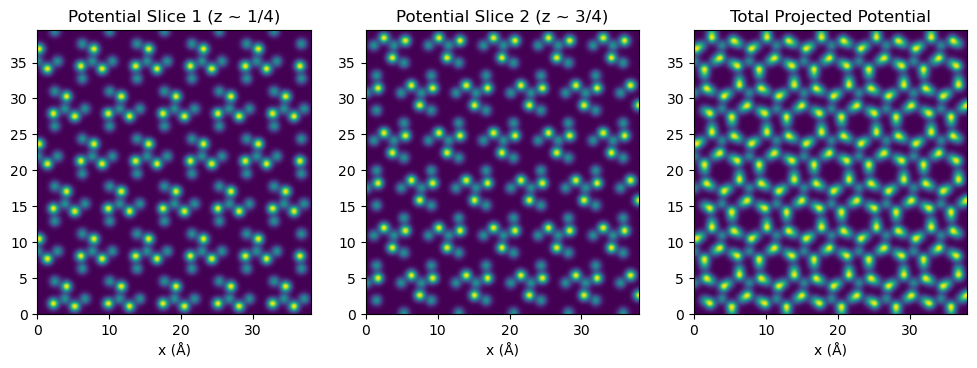

In [3]:
# Grid Setup
nx, ny = 256, 256
x = np.linspace(0, Sx, nx, endpoint=False)
y = np.linspace(0, Sy, ny, endpoint=False)
X, Y = np.meshgrid(x, y)

def calculate_projected_potential(atoms, Sx, Sy, nx, ny):
    """
    Calculate projected potential map V_proj(x,y) by summing contributions from all atoms.
    
    Physics:
    The projected potential is the integral of the electrostatic potential V(x,y,z) along z.
    We approximate the potential of individual atoms using Gaussians (scattering factors).
    """
    V = np.zeros((ny, nx))
    
    # Parameters for atomic potentials (Simplified Gaussian Model)
    # Strength is proportional to Atomic Number Z
    scale_Si = 14.0 * 2.0 
    scale_N = 7.0 * 2.0
    width = 0.5 # Width of the potential well [Angstroms]
    w2 = 2 * width**2

    for atom in atoms:
        elem, ax, ay, az = atom
        
        strength = scale_Si if elem == 'Si' else scale_N
        
        # Calculate distance from grid points to atom center (ax, ay)
        # Note: A rigorous implementation would use Periodic Boundary Conditions (PBC)
        # here to ensuring "wrapping" at edges. For this supercell Example, we simply
        # made the supercell large enough and populated it.
        dx = X - ax
        dy = Y - ay
        R2 = dx**2 + dy**2
        
        # Optimization: only compute for pixels close to the atom (< 3 Angstroms)
        mask = R2 < (3.0**2) 
        V[mask] += strength * np.exp(-R2[mask] / w2)
        
    return V

# --- Slicing Strategy ---
# Multislice requires the slice thickness (dz) to be small enough that the "Weak Phase Object"
# approximation holds within the slice.
# The c-axis repeat is c_hex = 2.909 Å.
# We split this unit cell into 2 slices based on the z-height of atoms.
# Slice 1: z < c/2  (Layer A)
# Slice 2: z >= c/2 (Layer B)

atoms_layer1 = [a for a in supercell_atoms if a[3] < c_hex/2]
atoms_layer2 = [a for a in supercell_atoms if a[3] >= c_hex/2]

print(f"Slice 1 atoms: {len(atoms_layer1)}")
print(f"Slice 2 atoms: {len(atoms_layer2)}")

# Calculate the potential map for each slice
V1 = calculate_projected_potential(atoms_layer1, Sx, Sy, nx, ny)
V2 = calculate_projected_potential(atoms_layer2, Sx, Sy, nx, ny)

V_full = V1 + V2

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(V1, cmap='viridis', extent=[0, Sx, 0, Sy])
plt.title('Potential Slice 1 (z ~ 1/4)')
plt.xlabel('x (Å)')

plt.subplot(1, 3, 2)
plt.imshow(V2, cmap='viridis', extent=[0, Sx, 0, Sy])
plt.title('Potential Slice 2 (z ~ 3/4)')
plt.xlabel('x (Å)')

plt.subplot(1, 3, 3)
plt.imshow(V_full, cmap='viridis', extent=[0, Sx, 0, Sy])
plt.title('Total Projected Potential')
plt.xlabel('x (Å)')
plt.show()

## 4. Multislice Propagation Loop

Propagate the electron wave through the specimen.
*   Initial state: Plane wave.
*   Loop: For each slice layer (1 and 2), apply Transmission ($e^{i \sigma V}$) and Propagation ($P(k)$).
*   Total thickness: $\sim 50$ Å ($\sim 17$ unit cells).

Simulating 17 unit cells (49.45 Å)...
Simulation complete.


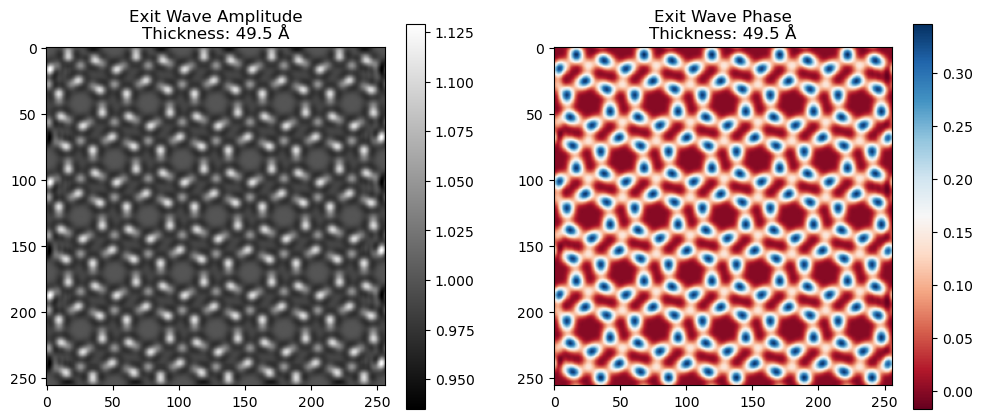

In [4]:
# --- 3. Fresnel Propagation (The "Multislice" Loop) ---

# A. Frequency Grid in Fourier Space (Reciprocal Space)
# We need k-vectors to calculate the propagator P(k).
# Standard numpy fftfreq gives frequencies in cycles/unit_length.
kx = np.fft.fftfreq(nx, d=Sx/nx)
ky = np.fft.fftfreq(ny, d=Sy/ny)
KX_freq, KY_freq = np.meshgrid(kx, ky)
K2 = KX_freq**2 + KY_freq**2

# B. Fresnel Propagator
# Propagates the electron wave over a distance dz in free space.
# Formula: P(k) = exp(-i * pi * lambda * dz * k^2)
# Here, k^2 is squared spatial frequency.
dz_slice = c_hex / 2.0  # Distance between our two slices
P = np.exp(-1j * np.pi * lam * dz_slice * K2)

# C. Transmission Functions
# The "Weak Phase Object" approximation applied at each slice.
# Formula: T(r) = exp(i * sigma * V_proj(r))
T1 = np.exp(1j * sigma * V1)
T2 = np.exp(1j * sigma * V2)

# D. Initialization
# Primary beam is a plane wave traveling down Z.
# psi(x,y) = 1 (constant amplitude, zero phase)
psi = np.ones((ny, nx), dtype=complex)

# E. The Loop
# We iterate through the thickness of the sample.
num_unit_cells = 17 
total_thickness = num_unit_cells * c_hex
print(f"Simulating {num_unit_cells} unit cells ({total_thickness:.2f} Å)...")

# Multislice Algorithm:
# 1. Propagate wave through vacuum (dz) -> FFT * P * IFFT
# 2. Transmit wave through potential -> psi * T
for i in range(num_unit_cells):
    # --- Step 1: Propagate to center of Slice 1 ---
    # Convolution in real space = Multiplication in Fourier space
    Psi_k = np.fft.fft2(psi)
    Psi_k *= P 
    psi = np.fft.ifft2(Psi_k)
    
    # --- Step 2: Interact with Slice 1 ---
    psi *= T1
    
    # --- Step 3: Propagate to center of Slice 2 ---
    Psi_k = np.fft.fft2(psi)
    Psi_k *= P
    psi = np.fft.ifft2(Psi_k)
    
    # --- Step 4: Interact with Slice 2 ---
    psi *= T2

exit_wave = psi
print("Simulation complete.")

# Visualizing Amplitude and Phase of the Exit Wave
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(np.abs(exit_wave), cmap='gray')
plt.title(f"Exit Wave Amplitude\nThickness: {total_thickness:.1f} Å")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(np.angle(exit_wave), cmap='RdBu') # Phase is usually more contrasty
plt.title(f"Exit Wave Phase\nThickness: {total_thickness:.1f} Å")
plt.colorbar()
plt.show()

## 5. Simulate Defocus Series

Apply the Contrast Transfer Function (CTF) to the exit wave to simulate images at Scherzer defocus and other values.
Requires spherical aberration $C_s \approx 1.0$ mm (typical).

Scherzer Defocus: -600.95 Å


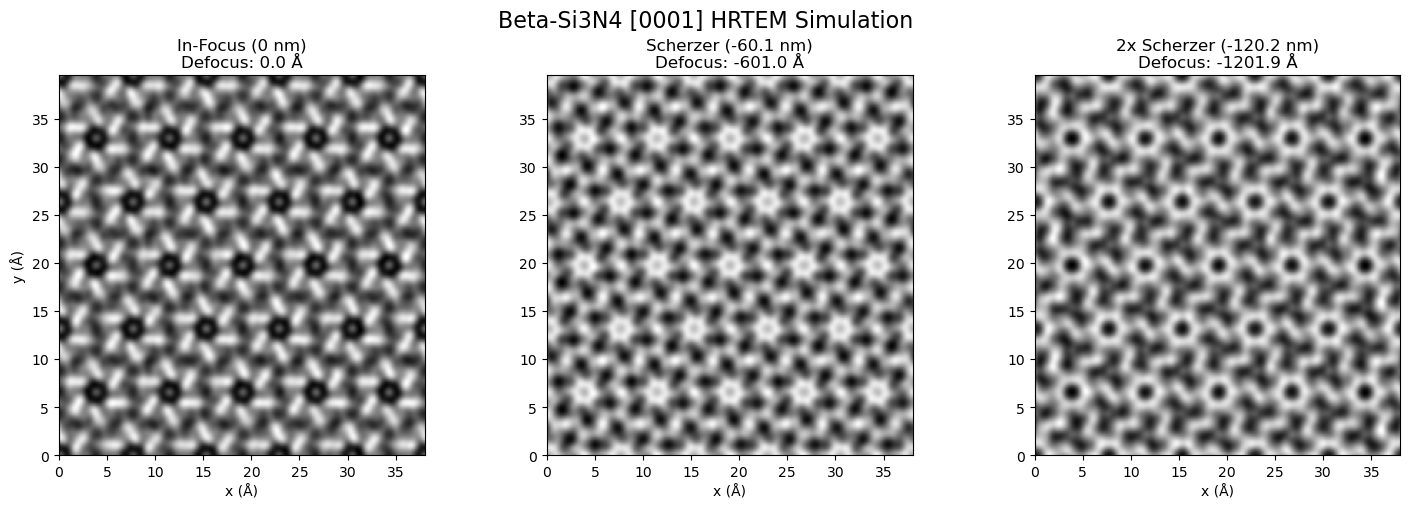

In [5]:
# --- 4. Image Formation (CTF Application) ---

# The "Exit Wave" is what leaves the bottom of the sample.
# The microscope lenses (Objective Lens) modify this wave before it hits the camera.
# This modification is described by the Contrast Transfer Function (CTF).

# Microscope Aberrations
Cs_mm = 1.0  # Spherical Aberration [mm]
Cs = Cs_mm * 1e7 # Convert to Angstroms

# Defocus values to simulate
# Scherzer Defocus is a standard condition for optimal phase contrast.
# df_sch = -1.2 * sqrt(Cs * lambda)
df_scherzer = -1.2 * np.sqrt(Cs * lam)
print(f"Scherzer Defocus: {df_scherzer:.2f} Å")

defocus_list = [0, df_scherzer, 2 * df_scherzer]
names = ["In-Focus (0 nm)", f"Scherzer ({df_scherzer/10:.1f} nm)", f"2x Scherzer ({2*df_scherzer/10:.1f} nm)"]

plt.figure(figsize=(15, 5))

for i, df in enumerate(defocus_list):
    # Setup CTF in Fourier Space
    # Phase shift chi(k)
    # chi = pi * lambda * k^2 * df + (pi/2) * Cs * lambda^3 * k^4
    # Note: Sign conventions vary! Here assuming df < 0 is underfocus.
    
    # Term 1: Defocus
    term1 = np.pi * lam * K2 * df
    
    # Term 2: Spherical Aberration
    term2 = (np.pi / 2.0) * Cs * (lam**3) * (K2**2)
    
    CTF_phase = term1 + term2
    
    # The pupil function includes the Aperture (omitted here for high-res) and Phase
    Pupil = np.exp(-1j * CTF_phase)
    
    # Apply CTF to the wave in Fourier domain
    # 1. FFT the exit wave
    Image_wave_k = np.fft.fft2(exit_wave)
    
    # 2. Multiply by Pupil/CTF
    Image_wave_k *= Pupil
    
    # 3. IFFT back to real space
    Image_wave = np.fft.ifft2(Image_wave_k)
    
    # 4. Detect Intensity (Modulus Squared)
    Intensity = np.abs(Image_wave)**2
    
    # Plotting
    plt.subplot(1, 3, i+1)
    plt.imshow(Intensity, cmap='gray', extent=[0, Sx, 0, Sy])
    plt.title(f"{names[i]}\nDefocus: {df:.1f} Å")
    plt.xlabel("x (Å)")
    if i == 0:
        plt.ylabel("y (Å)")

plt.suptitle("Beta-Si3N4 [0001] HRTEM Simulation", fontsize=16)
plt.tight_layout()
plt.show()